In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
from google.colab import files

uploaded = files.upload()  # Upload your downloaded CSV file here


Saving bq-results-20250414-162803-1744648095891.csv to bq-results-20250414-162803-1744648095891.csv


In [3]:
import pandas as pd

df = pd.read_csv('nyc_vehicles.csv')  # Replace with actual file name
df.head()


,crash_date,crash_time,borough,on_street,cross_street,contributing_factor,vehicle_type,persons_injured,persons_killed,lat,lon
0,2022-06-10,17:17:00,Unknown,AMBOY ROAD,Unknown,Alcohol Involvement,Station Wagon/Sport Utility Vehicle,1,0,40.509296,-74.246060
1,2022-04-19,06:00:00,Unknown,PAGE AVENUE,Unknown,Failure to Yield Right-of-Way,Station Wagon/Sport Utility Vehicle,1,0,40.520916,-74.235115
2,2022-06-06,16:16:00,Unknown,SOUTH SERVICE ROAD,Unknown,Animals Action,Sedan,1,0,40.526410,-74.219830
3,2022-07-17,03:45:00,Unknown,HYLAN BOULEVARD,Unknown,Tire Failure/Inadequate,Sedan,0,1,40.537262,-74.150510
4,2022-11-15,22:30:00,Unknown,BLOOMINGDALE ROAD,WOODROW ROAD,Failure to Yield Right-of-Way,Sedan,1,0,40.541122,-74.217800


Accidents by Contributing Factor

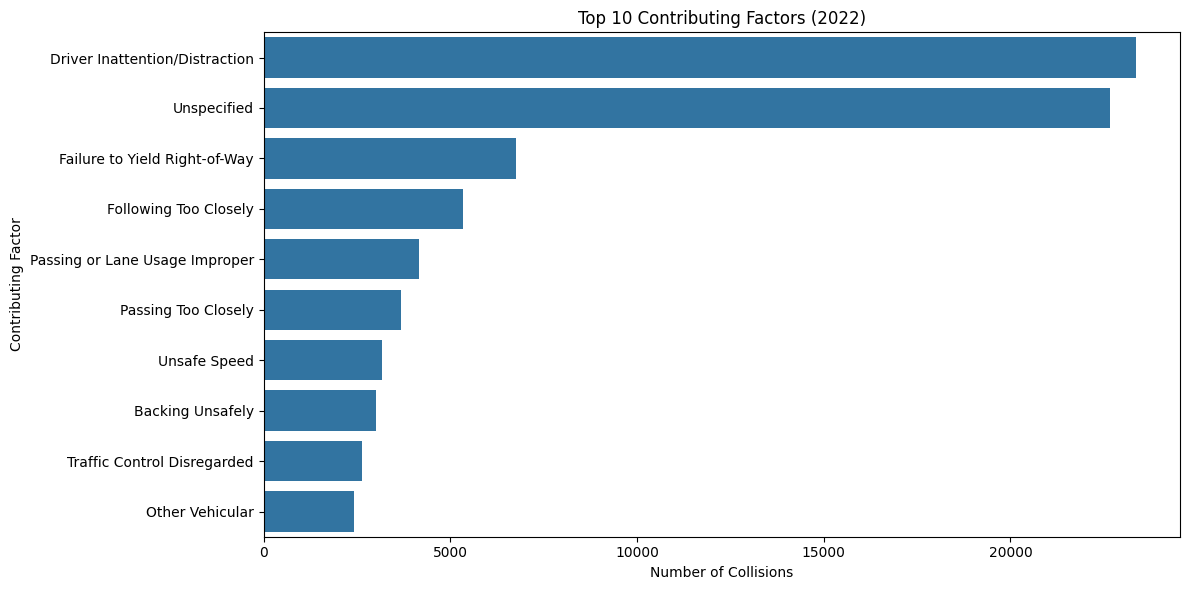

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

top_factors = df['contributing_factor'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_factors.values, y=top_factors.index)
plt.title('Top 10 Contributing Factors (2022)')
plt.xlabel('Number of Collisions')
plt.ylabel('Contributing Factor')
plt.tight_layout()
plt.show()


Collisions by Hour of Day

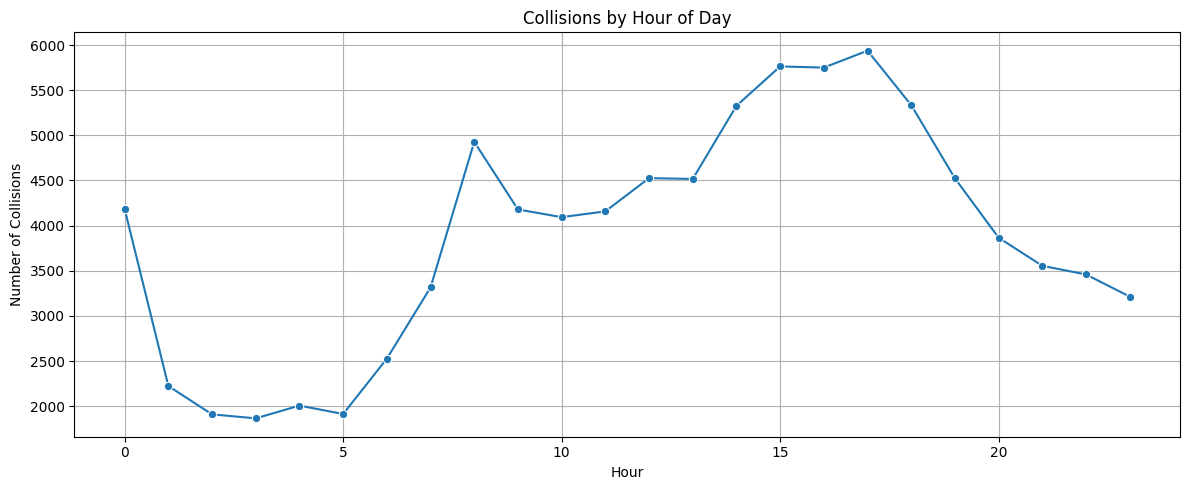

In [5]:
df['hour'] = pd.to_datetime(df['crash_time'], format='%H:%M:%S').dt.hour
hourly = df['hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o')
plt.title('Collisions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Collisions')
plt.grid(True)
plt.tight_layout()
plt.show()


Top 10 Dangerous Streets

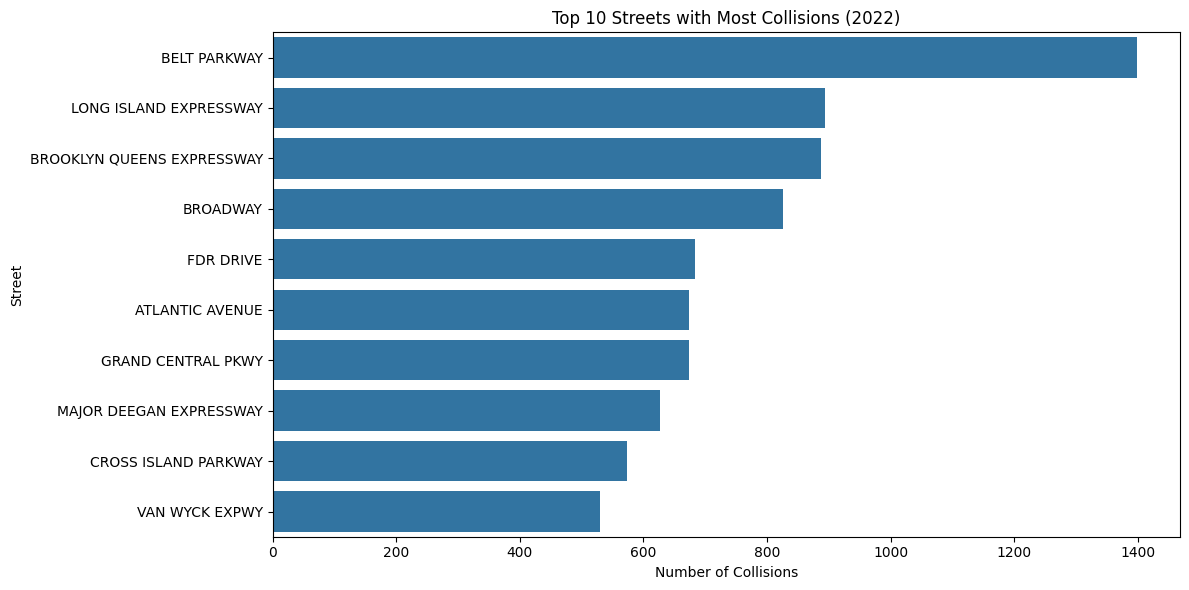

In [10]:
top_streets = df['on_street'].value_counts().drop('Unknown').head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_streets.values, y=top_streets.index)
plt.title('Top 10 Streets with Most Collisions (2022)')
plt.xlabel('Number of Collisions')
plt.ylabel('Street')
plt.tight_layout()
plt.show()


 Collisions by Borough

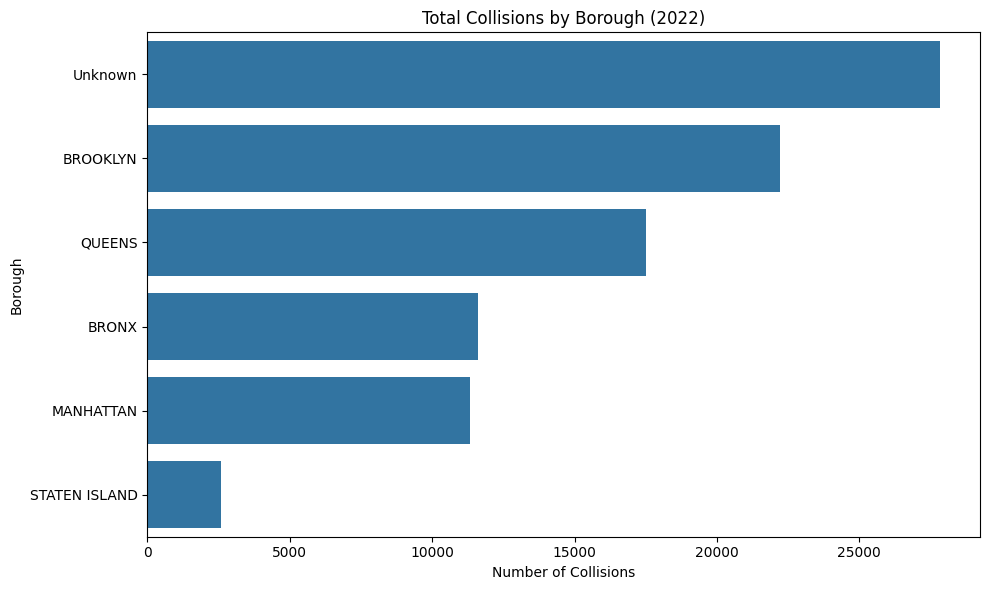

In [11]:
borough_counts = df['borough'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=borough_counts.values, y=borough_counts.index)
plt.title('Total Collisions by Borough (2022)')
plt.xlabel('Number of Collisions')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()


Map of Accidents

In [6]:
import folium
from folium.plugins import MarkerCluster

# Create a base map centered on NYC
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=10)
marker_cluster = MarkerCluster().add_to(nyc_map)

# Sample 1000 rows for map performance
sample_df = df[['lat', 'lon', 'on_street', 'contributing_factor']].dropna().sample(1000)

for i, row in sample_df.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=f"Street: {row['on_street']}<br>Cause: {row['contributing_factor']}"
    ).add_to(marker_cluster)

nyc_map


In [19]:
import folium
from folium.plugins import MarkerCluster
from folium.map import Icon

# Base NYC map
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB Positron')
marker_cluster = MarkerCluster().add_to(nyc_map)

# Sample 1000 rows for performance
map_df = df[['lat', 'lon', 'on_street', 'cross_street', 'borough', 'contributing_factor',
             'vehicle_type', 'persons_injured', 'persons_killed']].dropna().sample(1000)

# Add markers
for _, row in map_df.iterrows():
    # Set marker color based on severity
    if row['persons_killed'] > 0:
        icon_color = 'red'
    elif row['persons_injured'] > 0:
        icon_color = 'orange'
    else:
        icon_color = 'blue'

    # Marker popup info
    popup_text = (
        f"<b>Borough:</b> {row['borough']}<br>"
        f"<b>Street:</b> {row['on_street']} & {row['cross_street']}<br>"
        f"<b>Contributing Factor:</b> {row['contributing_factor']}<br>"
        f"<b>Vehicle Type:</b> {row['vehicle_type']}<br>"
        f"<b>Injured:</b> {int(row['persons_injured'])} | "
        f"<b>Killed:</b> {int(row['persons_killed'])}"
    )

    # Add marker
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=Icon(color=icon_color, icon='car', prefix='fa')
    ).add_to(marker_cluster)

from branca.element import Html

title_html = """
     <div style="
         position: fixed;
         top: 10px;
         left: 50%;
         transform: translateX(-50%);
         background-color: white;
         padding: 10px 20px;
         font-size: 20px;
         border-radius: 8px;
         box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
         z-index: 9999;
         text-align: center;
     ">
         🚦 <b>NYC Traffic Collisions Map - 2022</b><br>
         <span style="font-size:14px; color:gray;">Click on markers for more details</span>
     </div>
     """

# Add the title as a folium element
title_element = Html(title_html, script=True)
nyc_map.get_root().html.add_child(title_element)

# Save map
nyc_map.save("nyc_collisions_map.html")

